# Joint Agent-Count Sweep

Evaluate HAPPO with different physical UAV/UGV counts while preserving the checkpoint observation schema. The matrix shows confirmation AUC for each `[UAV, UGV]` combination; every cell is annotated as `mean +/- std`.

When `FILELIST` is empty, the notebook runs `scripts/diagnose_joint_physical_ablation_happo.py` for every configured combination. When files are supplied, agent counts are read from each JSON (with the filename used only as a fallback), so file order cannot transpose the matrix.


In [7]:
MODLABEL = 'uav4_ugv4_1km_256_agent_sweep'
CKPT = '/path/to/seed-.../models'
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1099

# Entries are [number of physical UAVs, number of physical UGVs].
AGENT_COMBINATIONS = [
    [2, 1], [2, 2], [2, 3],
    [3, 1], [3, 2], [3, 3],
    [4, 1], [4, 2], [4, 3],
]

TRAINED_COMBINATION = [4,3]

RUN_DIAGNOSTICS = True
FORCE_RERUN_DIAGNOSTICS = False
EXTRA_DIAGNOSTIC_ARGS = []

# Existing physical-ablation JSON files. Leave empty to run the sweep above.
FILELIST = [
    'outputs/agents/uav2_ugv1_1km_256_250_900_hid128_fire_nsurv_min5_max10_obs10_1000_1099.json',
    'outputs/agents/uav2_ugv2_1km_256_250_900_hid128_fire_nsurv_min5_max10_obs10_1000_1099.json',
    'outputs/agents/uav2_ugv3_1km_256_250_900_hid128_fire_nsurv_min5_max10_obs10_1000_1099.json',
    'outputs/agents/uav3_ugv1_1km_256_250_900_hid128_fire_nsurv_min5_max10_obs10_1000_1099.json',
    'outputs/agents/uav3_ugv2_1km_256_250_900_hid128_fire_nsurv_min5_max10_obs10_1000_1099.json',
    'outputs/agents/uav3_ugv3_1km_256_250_900_hid128_fire_nsurv_min5_max10_obs10_1000_1099.json',
    'outputs/agents/uav4_ugv1_1km_256_250_900_hid128_fire_nsurv_min5_max10_obs10_1000_1099.json',
    'outputs/agents/uav4_ugv2_1km_256_250_900_hid128_fire_nsurv_min5_max10_obs10_1000_1099.json',
    'outputs/agents/uav4_ugv3_1km_256_250_900_hid128_fire_nsurv_min5_max10_obs10_1000_1099.json',
]


In [8]:
import json
import re
import shlex
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

CWD = Path.cwd().resolve()
SCRIPT = Path('scripts/diagnose_joint_physical_ablation_happo.py')
if (CWD / SCRIPT).is_file():
    PROJECT_ROOT = CWD
elif (CWD.parent / SCRIPT).is_file():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError(f'Could not locate {SCRIPT}')

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'agents'


def _resolve_path(path):
    path = Path(path).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    return path.resolve()


def _output_paths(n_uavs, n_ugvs):
    stem = f'{MODLABEL}_uav{n_uavs}_ugv{n_ugvs}_{SEED_START}_{SEED_END}'
    return OUTPUT_DIR / f'{stem}.json', OUTPUT_DIR / f'{stem}.png'


def _payload_scenario(payload):
    for candidate in (
        payload.get('scenario'),
        payload.get('scenario_kwargs'),
        payload.get('metadata', {}).get('scenario_kwargs'),
    ):
        if isinstance(candidate, dict) and candidate:
            return candidate
    return {}


def _agent_counts(path, payload):
    scenario = _payload_scenario(payload)
    n_uavs = scenario.get('n_drones')
    n_ugvs = scenario.get('n_ground')
    if n_uavs is not None and n_ugvs is not None:
        return int(n_uavs), int(n_ugvs)

    match = re.search(r'uav(\d+)_ugv(\d+)', path.stem, flags=re.IGNORECASE)
    if match:
        return int(match.group(1)), int(match.group(2))
    raise ValueError(f'Could not determine UAV/UGV counts from {path}')


def _confirm_auc_stats(payload):
    summary = payload.get('summary', {})
    mean = summary.get('mean_confirm_auc')
    std = summary.get('std_confirm_auc')
    if mean is not None:
        return float(mean), float(std) if std is not None else float('nan')

    values = []
    for row in payload.get('rows', []):
        value = row.get('confirm_auc', row.get('confirmation_auc'))
        if isinstance(value, (int, float)) and np.isfinite(value):
            values.append(float(value))
    if not values:
        raise KeyError('Diagnostic JSON contains no confirmation AUC metric')
    return float(np.mean(values)), float(np.std(values))


def _confirm_auc_by_seed(payload):
    values = {}
    for row in payload.get('rows', []):
        seed = row.get('seed')
        value = row.get('confirm_auc', row.get('confirmation_auc'))
        if seed is not None and isinstance(value, (int, float)) and np.isfinite(value):
            values[int(seed)] = float(value)
    return values


In [9]:
expected_combinations = [tuple(map(int, combination)) for combination in AGENT_COMBINATIONS]
if len(expected_combinations) != len(set(expected_combinations)):
    raise ValueError('AGENT_COMBINATIONS contains duplicates')

if FILELIST:
    JSON_FILES = [_resolve_path(path) for path in FILELIST]
    print('Using provided files; diagnostics will not be run.')
else:
    checkpoint = _resolve_path(CKPT)
    if not checkpoint.is_dir():
        raise FileNotFoundError(f'Checkpoint directory not found: {checkpoint}')
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    seeds = [str(seed) for seed in range(SEED_START, SEED_END + 1)]
    JSON_FILES = []

    for n_uavs, n_ugvs in expected_combinations:
        json_output, plots_output = _output_paths(n_uavs, n_ugvs)
        if RUN_DIAGNOSTICS and (FORCE_RERUN_DIAGNOSTICS or not json_output.is_file()):
            cmd = [
                sys.executable,
                str(PROJECT_ROOT / SCRIPT),
                '--checkpoint-dir', str(checkpoint),
                '--n-uavs', str(n_uavs),
                '--n-ugvs', str(n_ugvs),
                '--steps', str(NSTEPS_PER_EPISODE),
                '--seeds', *seeds,
                '--json-output', str(json_output),
                '--plots-output', str(plots_output),
            ]
            cmd.extend(str(arg) for arg in EXTRA_DIAGNOSTIC_ARGS)
            log_path = json_output.with_suffix('.log')
            print('Running:', shlex.join(cmd))
            print('Log:', log_path)
            with log_path.open('w') as log:
                subprocess.run(
                    cmd,
                    cwd=PROJECT_ROOT,
                    check=True,
                    stdout=log,
                    stderr=subprocess.STDOUT,
                )
        else:
            print('Using existing diagnostics:', json_output)
        JSON_FILES.append(json_output)

missing = [path for path in JSON_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing diagnostic JSON files:\n' + '\n'.join(map(str, missing)))

print(f'Loaded {len(JSON_FILES)} diagnostic JSON file(s).')


Using provided files; diagnostics will not be run.
Loaded 9 diagnostic JSON file(s).


In [10]:
records = []
for path in JSON_FILES:
    payload = json.loads(path.read_text())
    n_uavs, n_ugvs = _agent_counts(path, payload)
    confirm_auc_mean, confirm_auc_std = _confirm_auc_stats(payload)
    records.append({
        'n_uavs': n_uavs,
        'n_ugvs': n_ugvs,
        'confirm_auc_mean': confirm_auc_mean,
        'confirm_auc_std': confirm_auc_std,
        'confirm_auc_by_seed': _confirm_auc_by_seed(payload),
        'episode_count': int(payload.get('summary', {}).get('episodes', len(payload.get('rows', [])))),
        'file': str(path),
    })

metrics = pd.DataFrame.from_records(records)
duplicate_counts = metrics.groupby(['n_uavs', 'n_ugvs']).size()
duplicates = duplicate_counts[duplicate_counts > 1]
if not duplicates.empty:
    raise ValueError(f'Multiple files describe the same agent combination:\n{duplicates}')

unexpected = set(zip(metrics['n_uavs'], metrics['n_ugvs'])) - set(expected_combinations)
if unexpected:
    raise ValueError(f'FILELIST contains combinations not listed in AGENT_COMBINATIONS: {sorted(unexpected)}')

metrics.sort_values(['n_uavs', 'n_ugvs']).reset_index(drop=True)


,n_uavs,n_ugvs,confirm_auc_mean,confirm_auc_std,confirm_auc_by_seed,file
0,2,1,0.319883,0.082619,"{1000: 0.41345679012345704, 1001: 0.2450000000...",/Users/aschuetz/Software/capstone/omnisearch/o...
1,2,2,0.432169,0.098810,"{1000: 0.6802222222222225, 1001: 0.19269841269...",/Users/aschuetz/Software/capstone/omnisearch/o...
2,2,3,0.473086,0.110669,"{1000: 0.3995238095238109, 1001: 0.28805555555...",/Users/aschuetz/Software/capstone/omnisearch/o...
3,3,1,0.360940,0.087793,"{1000: 0.2902222222222214, 1001: 0.34682539682...",/Users/aschuetz/Software/capstone/omnisearch/o...
4,3,2,0.503964,0.100173,"{1000: 0.4898412698412716, 1001: 0.53333333333...",/Users/aschuetz/Software/capstone/omnisearch/o...
5,3,3,0.556572,0.084662,"{1000: 0.4997777777777773, 1001: 0.59166666666...",/Users/aschuetz/Software/capstone/omnisearch/o...
6,4,1,0.380320,0.093942,"{1000: 0.3488888888888882, 1001: 0.17125, 1002...",/Users/aschuetz/Software/capstone/omnisearch/o...
7,4,2,0.537908,0.098846,"{1000: 0.6542222222222227, 1001: 0.64611111111...",/Users/aschuetz/Software/capstone/omnisearch/o...
8,4,3,0.609077,0.078328,"{1000: 0.5492222222222174, 1001: 0.62285714285...",/Users/aschuetz/Software/capstone/omnisearch/o...


## Confirmation AUC Matrix

Rows are the number of physical UAVs and columns are the number of physical UGVs. Color represents mean confirmation AUC; annotations show `mean +/- std` across evaluation seeds.


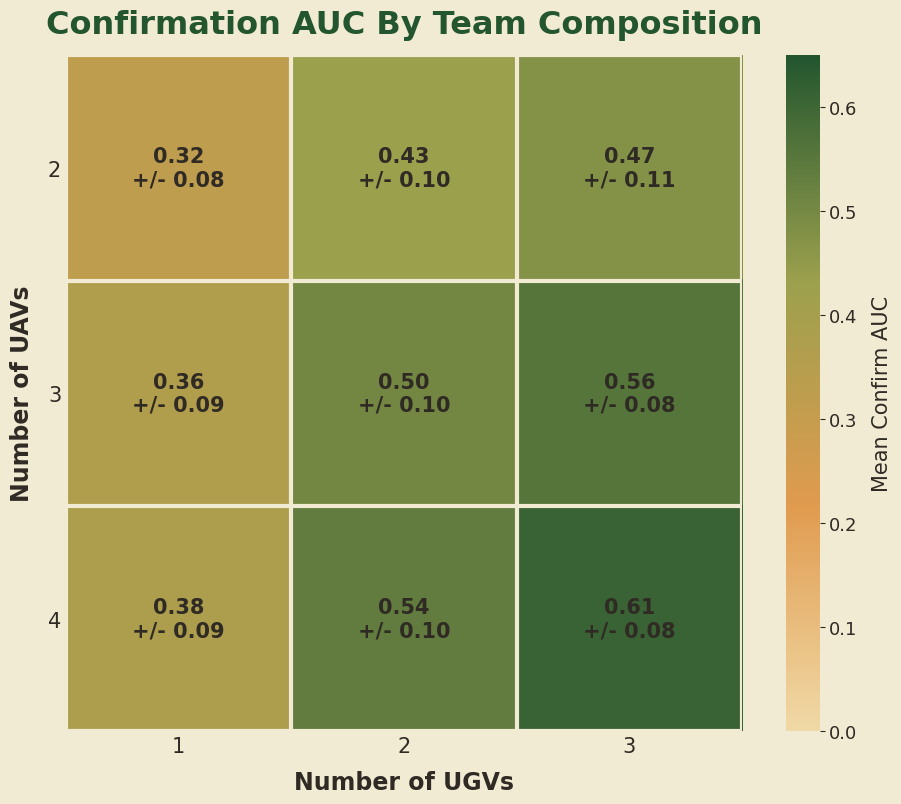

In [11]:
PAPER_BG = '#f2ebd3ff'
TEXT_GREEN = '#23562f'
TEXT_DARK = '#2f2a24'
MISSING_COLOR = '#d8d1bd'

uav_counts = sorted({n_uavs for n_uavs, _ in expected_combinations})
ugv_counts = sorted({n_ugvs for _, n_ugvs in expected_combinations})
mean_matrix = np.full((len(uav_counts), len(ugv_counts)), np.nan)
std_matrix = np.full_like(mean_matrix, np.nan)
uav_index = {value: index for index, value in enumerate(uav_counts)}
ugv_index = {value: index for index, value in enumerate(ugv_counts)}

for row in metrics.itertuples(index=False):
    y = uav_index[row.n_uavs]
    x = ugv_index[row.n_ugvs]
    mean_matrix[y, x] = row.confirm_auc_mean
    std_matrix[y, x] = row.confirm_auc_std

cmap = LinearSegmentedColormap.from_list(
    'paper_confirm_auc',
    ['#f0d9a6', '#e09b4f', '#9ba04d', '#23562f'],
)
cmap.set_bad(MISSING_COLOR)

fig, ax = plt.subplots(
    figsize=(2.25 * len(ugv_counts) + 3.0, 1.85 * len(uav_counts) + 2.6),
    facecolor=PAPER_BG,
)
ax.set_facecolor(PAPER_BG)
image = ax.imshow(np.ma.masked_invalid(mean_matrix), cmap=cmap, vmin=0.0, vmax=0.65, aspect='equal')

for y in range(len(uav_counts)):
    for x in range(len(ugv_counts)):
        mean = mean_matrix[y, x]
        std = std_matrix[y, x]
        if np.isfinite(mean):
            annotation = f'{mean:.2f}\n+/- {std:.2f}' if np.isfinite(std) else f'{mean:.2f}'
            color = 'white' if mean >= 0.62 else TEXT_DARK
        else:
            annotation = 'n/a'
            color = '#6f6758'
        ax.text(x, y, annotation, ha='center', va='center', color=color, fontsize=15, fontweight='bold')

ax.set_xticks(np.arange(len(ugv_counts)), labels=ugv_counts)
ax.set_yticks(np.arange(len(uav_counts)), labels=uav_counts)
ax.set_xlabel('Number of UGVs', fontsize=17, fontweight='bold', color=TEXT_DARK, labelpad=10)
ax.set_ylabel('Number of UAVs', fontsize=17, fontweight='bold', color=TEXT_DARK, labelpad=10)
ax.set_title('Confirmation AUC By Team Composition', fontsize=23, fontweight='bold', color=TEXT_GREEN, pad=16)
ax.tick_params(axis='both', labelsize=15, colors=TEXT_DARK, length=0)
ax.set_xticks(np.arange(-0.5, len(ugv_counts), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(uav_counts), 1), minor=True)
ax.grid(which='minor', color=PAPER_BG, linewidth=3)
ax.tick_params(which='minor', bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = fig.colorbar(image, ax=ax, fraction=0.045, pad=0.05)
colorbar.set_label('Mean Confirm AUC', fontsize=15, color=TEXT_DARK, labelpad=10)
colorbar.ax.tick_params(labelsize=13, colors=TEXT_DARK)
colorbar.outline.set_visible(False)
fig.tight_layout()
plt.show()


## Degradation Relative To The Trained Composition

Each cell shows the paired confirmation-AUC change relative to `TRAINED_COMBINATION`, in percentage points. Negative values mean worse performance than the trained composition; positive values mean improvement. Uncertainty is the 95% confidence interval of the mean paired change across matching seeds.


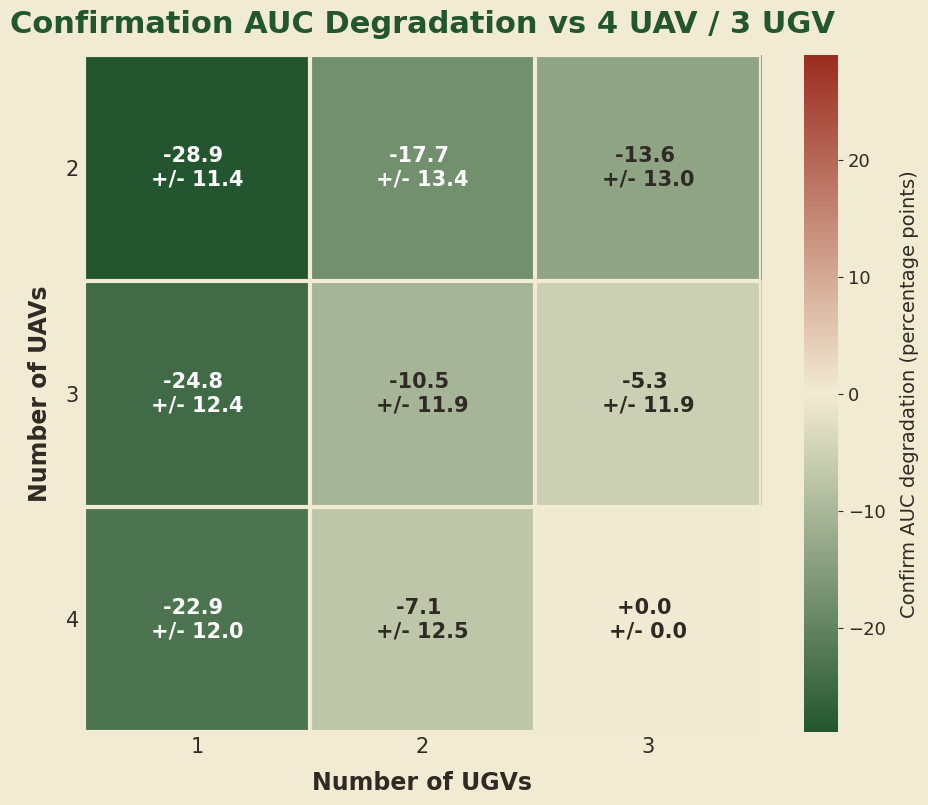

In [14]:
trained_combination = tuple(map(int, TRAINED_COMBINATION))
if trained_combination not in expected_combinations:
    raise ValueError(f'TRAINED_COMBINATION {trained_combination} is not in AGENT_COMBINATIONS')

trained_rows = metrics[
    (metrics['n_uavs'] == trained_combination[0])
    & (metrics['n_ugvs'] == trained_combination[1])
]
if len(trained_rows) != 1:
    raise ValueError(f'Expected exactly one result for TRAINED_COMBINATION={trained_combination}')
trained_row = trained_rows.iloc[0]
trained_by_seed = trained_row['confirm_auc_by_seed']


def _degradation_stats(row):
    combination = (int(row['n_uavs']), int(row['n_ugvs']))
    if combination == trained_combination:
        return 0.0, 0.0, len(trained_by_seed)

    current_by_seed = row['confirm_auc_by_seed']
    common_seeds = sorted(set(trained_by_seed) & set(current_by_seed))
    if common_seeds:
        paired = np.asarray([
            current_by_seed[seed] - trained_by_seed[seed]
            for seed in common_seeds
        ], dtype=float)
        sample_std = float(np.std(paired, ddof=1)) if len(paired) > 1 else float('nan')
        ci95 = 1.96 * sample_std / np.sqrt(len(paired)) if len(paired) > 1 else float('nan')
        return 100.0 * float(np.mean(paired)), 100.0 * ci95, len(common_seeds)

    # Compatibility fallback for older summaries without per-seed AUC values.
    mean = 100.0 * (row['confirm_auc_mean'] - trained_row['confirm_auc_mean'])
    trained_count = max(int(trained_row['episode_count']), 1)
    current_count = max(int(row['episode_count']), 1)
    ci95 = 1.96 * 100.0 * np.sqrt(
        trained_row['confirm_auc_std'] ** 2 / trained_count
        + row['confirm_auc_std'] ** 2 / current_count
    )
    return float(mean), float(ci95), 0


degradation_matrix = np.full_like(mean_matrix, np.nan)
degradation_ci95_matrix = np.full_like(mean_matrix, np.nan)
paired_seed_count_matrix = np.zeros_like(mean_matrix, dtype=int)
for _, row in metrics.iterrows():
    y = uav_index[int(row['n_uavs'])]
    x = ugv_index[int(row['n_ugvs'])]
    degradation, degradation_ci95, paired_count = _degradation_stats(row)
    degradation_matrix[y, x] = degradation
    degradation_ci95_matrix[y, x] = degradation_ci95
    paired_seed_count_matrix[y, x] = paired_count

finite_degradation = np.abs(degradation_matrix[np.isfinite(degradation_matrix)])
color_limit = max(float(np.max(finite_degradation)) if finite_degradation.size else 0.0, 1.0)
degradation_cmap = LinearSegmentedColormap.from_list(
    'paper_degradation',
    ['#9b2d20', PAPER_BG, '#23562f'],
)
degradation_cmap.set_bad(MISSING_COLOR)
degradation_norm = TwoSlopeNorm(vmin=-color_limit, vcenter=0.0, vmax=color_limit)

fig, ax = plt.subplots(
    figsize=(2.25 * len(ugv_counts) + 3.0, 1.85 * len(uav_counts) + 2.6),
    facecolor=PAPER_BG,
)
ax.set_facecolor(PAPER_BG)
image = ax.imshow(
    np.ma.masked_invalid(degradation_matrix),
    cmap=degradation_cmap,
    norm=degradation_norm,
    aspect='equal',
)

for y in range(len(uav_counts)):
    for x in range(len(ugv_counts)):
        mean = degradation_matrix[y, x]
        ci95 = degradation_ci95_matrix[y, x]
        if np.isfinite(mean):
            annotation = f'{mean:+.1f} pp\n+/- {ci95:.1f} (95% CI)' if np.isfinite(ci95) else f'{mean:+.1f} pp'
            color = 'white' if abs(mean) >= 0.58 * color_limit else TEXT_DARK
        else:
            annotation = 'n/a'
            color = '#6f6758'
        ax.text(x, y, annotation, ha='center', va='center', color=color, fontsize=15, fontweight='bold')

ax.set_xticks(np.arange(len(ugv_counts)), labels=ugv_counts)
ax.set_yticks(np.arange(len(uav_counts)), labels=uav_counts)
ax.set_xlabel('Number of UGVs', fontsize=17, fontweight='bold', color=TEXT_DARK, labelpad=10)
ax.set_ylabel('Number of UAVs', fontsize=17, fontweight='bold', color=TEXT_DARK, labelpad=10)
ax.set_title(
    f'Confirmation AUC Change vs {trained_combination[0]} UAV / {trained_combination[1]} UGV',
    fontsize=22,
    fontweight='bold',
    color=TEXT_GREEN,
    pad=16,
)
ax.tick_params(axis='both', labelsize=15, colors=TEXT_DARK, length=0)
ax.set_xticks(np.arange(-0.5, len(ugv_counts), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(uav_counts), 1), minor=True)
ax.grid(which='minor', color=PAPER_BG, linewidth=3)
ax.tick_params(which='minor', bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = fig.colorbar(image, ax=ax, fraction=0.045, pad=0.05)
colorbar.set_label('Confirm AUC change (percentage points)', fontsize=14, color=TEXT_DARK, labelpad=10)
colorbar.ax.tick_params(labelsize=13, colors=TEXT_DARK)
colorbar.outline.set_visible(False)
fig.tight_layout()
plt.show()
